In [1]:
####################  Data Analysis & Calculation  #####################3
import numpy as np   
import pandas as pd  
import datetime  

####################  Visuvalization & plotting  #####################3
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline  
#################### Machine Learning #####################3
from sklearn.ensemble import AdaBoostClassifier  
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
import warnings  
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder 

In [2]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Number of rows
n = 10000

# Sample values


product_categories = ['Electronics', 'Clothing', 'Books']

products = {
    'Electronics': ['Mobile', 'Laptop'],
    'Clothing': ['T-Shirt', 'Jeans'],
    'Books': ['Novel', 'Textbook']
}

types = {
    'Mobile': ['Android', 'iOS'],
    'Laptop': ['Gaming', 'Ultrabook'],
    'T-Shirt': ['Round Neck', 'V-Neck'],
    'Jeans': ['Slim', 'Regular'],
    'Novel': ['Fiction', 'Mystery'],
    'Textbook': ['Math', 'Science']
}



# product_categories = ['Electronics', 'Clothing', 'Home', 'Books', 'Toys']
# products = {
#     'Electronics': ['Mobile', 'Laptop', 'Headphones'],
#     'Clothing': ['T-Shirt', 'Jeans', 'Jacket'],
#     'Home': ['Chair', 'Lamp', 'Table'],
#     'Books': ['Novel', 'Biography', 'Textbook'],
#     'Toys': ['Puzzle', 'Doll', 'Car']
# }
# types = {
#     'Mobile': ['Android', 'iOS'],
#     'Laptop': ['Gaming', 'Ultrabook'],
#     'Headphones': ['Wireless', 'Wired'],
#     'T-Shirt': ['Round Neck', 'V-Neck'],
#     'Jeans': ['Slim', 'Regular'],
#     'Jacket': ['Leather', 'Denim'],
#     'Chair': ['Office', 'Dining'],
#     'Lamp': ['LED', 'Halogen'],
#     'Table': ['Coffee', 'Study'],
#     'Novel': ['Fiction', 'Mystery'],
#     'Biography': ['Historical', 'Celebrity'],
#     'Textbook': ['Math', 'Science'],
#     'Puzzle': ['Jigsaw', '3D'],
#     'Doll': ['Barbie', 'Action'],
#     'Car': ['Electric', 'Remote Control']
# }

# Base timestamp
start_time = datetime(2024, 1, 1, 9, 0, 0)

# Generate data
data = []
for i in range(n):
    category = random.choice(product_categories)
    product = random.choice(products[category])
    prod_type = random.choice(types[product])
    price = round(np.random.normal(loc=500, scale=200), 2)
    price = max(price, 50)  # minimum price
    num_clicks = np.random.poisson(3)
    added_to_cart_flag = np.random.choice([0, 1], p=[0.7, 0.3])
    # purchased_flag = 1 if added_to_cart_flag and num_clicks > 2 and random.random() < 0.5 else 0
    # purchased_flag = 1 if added_to_cart_flag and num_clicks > 2 and random.random() < 0.9 else 0

    if added_to_cart_flag:
        if num_clicks >= 3:
            purchased_flag = 1 if random.random() < 0.6 else 0  # 60% likely
        else:
            purchased_flag = 1 if random.random() < 0.2 else 0  # 20% likely
    else:
        purchased_flag = 1 if random.random() < 0.05 else 0     # 5% likely

    
    # Convert to "Yes"/"No"
    added_to_cart = "Yes" if added_to_cart_flag else "No"
    purchased = "Yes" if purchased_flag else "No"
    
    # Generate timestamp with some spacing
    timestamp = start_time + timedelta(minutes=random.randint(0, n*2))

    data.append([
        timestamp, category, product, prod_type, price,
        num_clicks, added_to_cart, purchased
    ])

# Create DataFrame
df = pd.DataFrame(data, columns=[
    'timestamp', 'product_category', 'product', 'type',
    'price', 'num_clicks', 'added_to_cart', 'purchased'
])

# Save to CSV (optional)



In [3]:
df.head()

,timestamp,product_category,product,type,price,num_clicks,added_to_cart,purchased
0,2024-01-06 22:44:00,Books,Novel,Fiction,599.34,3,No,No
1,2024-01-13 18:50:00,Electronics,Mobile,Android,472.35,3,Yes,No
2,2024-01-06 08:24:00,Electronics,Laptop,Gaming,406.11,1,No,Yes
3,2024-01-13 18:36:00,Electronics,Mobile,Android,608.51,3,No,No
4,2024-01-01 12:32:00,Clothing,T-Shirt,V-Neck,318.40,3,No,No


In [144]:
df.loc[1883]

product_category    Electronics
product                  Mobile
type                    Android
price                    822.06
num_clicks                    6
added_to_cart               Yes
purchased                   Yes
Name: 1883, dtype: object

In [4]:
df.columns

Index(['timestamp', 'product_category', 'product', 'type', 'price',
       'num_clicks', 'added_to_cart', 'purchased'],
      dtype='object')

In [5]:
np.sum(df['purchased']=='Yes')

1627

In [6]:
df.columns

Index(['timestamp', 'product_category', 'product', 'type', 'price',
       'num_clicks', 'added_to_cart', 'purchased'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         10000 non-null  datetime64[ns]
 1   product_category  10000 non-null  object        
 2   product           10000 non-null  object        
 3   type              10000 non-null  object        
 4   price             10000 non-null  float64       
 5   num_clicks        10000 non-null  int64         
 6   added_to_cart     10000 non-null  object        
 7   purchased         10000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 625.1+ KB


In [8]:
df = df.drop(['timestamp'], axis=1)

In [9]:
df.head()

,product_category,product,type,price,num_clicks,added_to_cart,purchased
0,Books,Novel,Fiction,599.34,3,No,No
1,Electronics,Mobile,Android,472.35,3,Yes,No
2,Electronics,Laptop,Gaming,406.11,1,No,Yes
3,Electronics,Mobile,Android,608.51,3,No,No
4,Clothing,T-Shirt,V-Neck,318.40,3,No,No


In [10]:
df.columns

Index(['product_category', 'product', 'type', 'price', 'num_clicks',
       'added_to_cart', 'purchased'],
      dtype='object')

## EDA

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_category  10000 non-null  object 
 1   product           10000 non-null  object 
 2   type              10000 non-null  object 
 3   price             10000 non-null  float64
 4   num_clicks        10000 non-null  int64  
 5   added_to_cart     10000 non-null  object 
 6   purchased         10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


In [13]:
df.isna().sum()

product_category    0
product             0
type                0
price               0
num_clicks          0
added_to_cart       0
purchased           0
dtype: int64

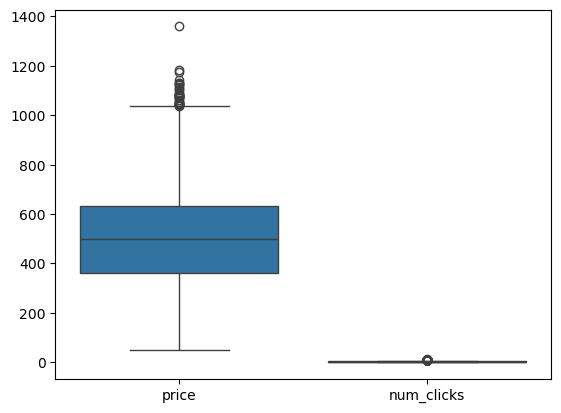

In [14]:
sns.boxplot(df)
plt.show()

In [15]:
for i in ['price', 'num_clicks']:
    if df[i].dtypes in ("float64", "int64"):
        q1 = df[i].quantile(0.25)
        q3 = df[i].quantile(0.75)
        iqr = q3 - q1
        ul = q3 + 1.5 * iqr
        ll = q1 - 1.5 * iqr
        df[i].clip(lower=ll, upper=ul, inplace=True)


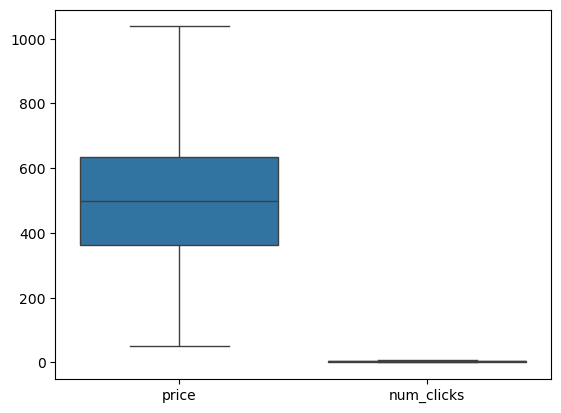

In [16]:
sns.boxplot(df)
plt.show()

# Breaking data in two parts

In [18]:
num=df.select_dtypes(include=[np.number])
cat=df.select_dtypes(include=['object'])

In [19]:
num.head()

,price,num_clicks
0,599.34,3
1,472.35,3
2,406.11,1
3,608.51,3
4,318.40,3


In [20]:
num.columns

Index(['price', 'num_clicks'], dtype='object')

In [21]:
cat.columns

Index(['product_category', 'product', 'type', 'added_to_cart', 'purchased'], dtype='object')

In [22]:
cat.head()

,product_category,product,type,added_to_cart,purchased
0,Books,Novel,Fiction,No,No
1,Electronics,Mobile,Android,Yes,No
2,Electronics,Laptop,Gaming,No,Yes
3,Electronics,Mobile,Android,No,No
4,Clothing,T-Shirt,V-Neck,No,No


# label encoder on categorical columns

In [24]:
from sklearn.preprocessing import LabelEncoder

cat = cat.apply(LabelEncoder().fit_transform) 


In [25]:
cat.head()

,product_category,product,type,added_to_cart,purchased
0,0,3,1,0,0
1,2,2,0,1,0
2,2,1,2,0,1
3,2,2,0,0,0
4,1,4,10,0,0


In [26]:
num.head()

,price,num_clicks
0,599.34,3
1,472.35,3
2,406.11,1
3,608.51,3
4,318.40,3


# combining data

In [28]:
df_final=pd.concat([num,cat],axis=1)

In [29]:
df_final.head()

,price,num_clicks,product_category,product,type,added_to_cart,purchased
0,599.34,3,0,3,1,0,0
1,472.35,3,2,2,0,1,0
2,406.11,1,2,1,2,0,1
3,608.51,3,2,2,0,0,0
4,318.40,3,1,4,10,0,0


In [30]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             10000 non-null  float64
 1   num_clicks        10000 non-null  int64  
 2   product_category  10000 non-null  int32  
 3   product           10000 non-null  int32  
 4   type              10000 non-null  int32  
 5   added_to_cart     10000 non-null  int32  
 6   purchased         10000 non-null  int32  
dtypes: float64(1), int32(5), int64(1)
memory usage: 351.7 KB


# Data partition 

In [32]:
x = df_final.drop('purchased', axis= 1)
y = df_final[['purchased']]
 
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size = 0.7 ,random_state=264)

In [33]:
xtrain.head()

,price,num_clicks,product_category,product,type,added_to_cart
6868,602.94,2,0,5,7,0
5811,115.33,3,2,2,0,0
283,578.36,4,1,0,5,0
9317,492.28,2,0,5,3,0
5920,563.46,1,0,5,3,1


In [34]:
ytrain.head()

,purchased
6868,0
5811,0
283,0
9317,0
5920,0


# Decision tree model 

### grid search cv

In [37]:
# params = { 'min_samples_split': [10,20,30,40,50], ## Parent 
#            'min_samples_leaf': [5,10,15,20,25], ## Child or Leave 
#            'max_depth':[4,5,6,7]}  # Branches

# from sklearn.tree import DecisionTreeClassifier
# from sklearn.model_selection import GridSearchCV

# grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42),
#                               params, 
#                               verbose=1, 
#                               cv=5)
# grid_search_cv.fit(xtrain, ytrain)

# grid_search_cv.best_estimator_



# from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor

# dt = DecisionTreeClassifier(
#     **grid_search_cv.best_estimator_.get_params()
# )
# dt.fit(xtrain,ytrain)  

# train=pd.concat([xtrain,ytrain],axis=1)

# train.head()

# train['predicted_dt']=dt.predict(xtrain)

# train.head()

# np.sum(train['purchased']==1)

# np.sum(train['predicted_dt']==1)

# from sklearn.metrics import classification_report
# print(classification_report(train['purchased'], train['predicted_dt']))

# ### prediction on test

# test=pd.concat([xtest,ytest],axis=1)


# test.head()

# test['predicted_dt']=dt.predict(xtest)

# test.head()

# from sklearn.metrics import classification_report
# print(classification_report(test['purchased'], test['predicted_dt']))



# Random Forest model 

In [39]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestClassifier # y = Category

# ### grid search 

# params = { 'min_samples_split': [50,100], ## Parent 
#            'min_samples_leaf': [25,50], ## Child or Leave 
#            'max_depth':[3,4,5]}  # Branches



# grid_search_cv = GridSearchCV(RandomForestClassifier(random_state=42,class_weight='balanced'),
#                               params, 
#                               verbose=1, 
#                               cv=10)
# grid_search_cv.fit(xtrain, ytrain)

# grid_search_cv.best_estimator_

# from sklearn.ensemble import RandomForestRegressor  # y = Number
# from sklearn.ensemble import RandomForestClassifier # y = Category

# # by default 100 tree will be form 
# RFModel = RandomForestClassifier(**grid_search_cv.best_estimator_.get_params()
#                             # random_state=42,
#                             #    n_estimators=25, # make 25 tress
#                             #    criterion="gini",
#                             #    max_depth=3,  # each tree will have 4 branches
#                             #    min_samples_split=50,# each tree will have parent node
#                             #    min_samples_leaf=25,# each tree will have Child node
#                             #    max_features="sqrt"
#                                 )# Variable selection in each tree  

# RFModel.fit(xtrain, ytrain)

# train=pd.concat([xtrain,ytrain],axis=1)

# train.head()

# train['predicted_pb_rf']=RFModel.predict_proba(xtrain)[:,1]


# train.head()

# train['predicted_rf']=train['predicted_pb_rf'].apply(lambda x:1 if x>=0.62 else 0)

# train.head()

# np.sum(train['purchased'])

# np.sum(train['predicted_rf'])

# from sklearn.metrics import classification_report
# print(classification_report(train['purchased'], train['predicted_rf']))

# print(ytrain.value_counts())


# Ada Boost

### grid search method 

In [42]:
model_parameters = {'n_estimators': [30, 50, 100, 150],  # number of Tree (Weak Model)
                    'learning_rate': [ 0.4,0.6, 0.8, 1]}

In [43]:
abc = AdaBoostClassifier() 
gscv_ADA = GridSearchCV(estimator=abc, 
                    param_grid=model_parameters, 
                    cv=10, 
                    verbose=1, ### message how many task done at backend
                    n_jobs=-1, ## parallel processing used entire processor
                    scoring='accuracy') ## accuracy evaluation

gscv_ADA.fit(xtrain,ytrain)

Fitting 10 folds for each of 16 candidates, totalling 160 fits


GridSearchCV(cv=10, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.4, 0.6, 0.8, 1],
                         'n_estimators': [30, 50, 100, 150]},
             scoring='accuracy', verbose=1)

In [44]:
print('The best parameter are -', gscv_ADA.best_params_)

The best parameter are - {'learning_rate': 1, 'n_estimators': 150}


In [45]:
# Re-fit the model with the best parameters
final_mod_ADA = AdaBoostClassifier(**gscv_ADA.best_params_)
final_mod_ADA.fit(xtrain,ytrain)

AdaBoostClassifier(learning_rate=1, n_estimators=150)

# prediction train

In [47]:
train_pred = final_mod_ADA.predict(xtrain)

In [48]:
train=pd.concat([xtrain,ytrain],axis=1)

In [49]:
train.head()

,price,num_clicks,product_category,product,type,added_to_cart,purchased
6868,602.94,2,0,5,7,0,0
5811,115.33,3,2,2,0,0,0
283,578.36,4,1,0,5,0,0
9317,492.28,2,0,5,3,0,0
5920,563.46,1,0,5,3,1,0


In [50]:
train['predicted_purchased'] = train_pred

In [140]:
train.head()

,price,num_clicks,product_category,product,type,added_to_cart,purchased,predicted_purchased
6868,602.94,2,0,5,7,0,0,0
5811,115.33,3,2,2,0,0,0,0
283,578.36,4,1,0,5,0,0,0
9317,492.28,2,0,5,3,0,0,0
5920,563.46,1,0,5,3,1,0,0


In [128]:
xtrain.columns

Index(['price', 'num_clicks', 'product_category', 'product', 'type',
       'added_to_cart'],
      dtype='object')

In [134]:
np.sum(train['purchased']==1)

1139

In [136]:
np.sum(train['predicted_purchased']==1)

583

# classification report train data 

In [55]:
print('Classification report for train data is : \n',
      classification_report(ytrain, train_pred))

Classification report for train data is : 
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      5861
           1       0.62      0.32      0.42      1139

    accuracy                           0.86      7000
   macro avg       0.75      0.64      0.67      7000
weighted avg       0.84      0.86      0.84      7000



# prediction test

In [57]:
test_pred = final_mod_ADA.predict(xtest)

In [58]:
test=pd.concat([xtest,ytest],axis=1)

In [59]:
test.head()

,price,num_clicks,product_category,product,type,added_to_cart,purchased
4606,122.28,7,0,3,1,0,0
8395,490.19,4,1,0,8,0,0
8766,176.75,2,1,4,6,0,0
1792,438.10,2,0,3,1,0,0
5175,633.73,3,2,2,0,1,1


In [60]:
test['predicted_purchased'] = test_pred

In [61]:
test.head()

,price,num_clicks,product_category,product,type,added_to_cart,purchased,predicted_purchased
4606,122.28,7,0,3,1,0,0,0
8395,490.19,4,1,0,8,0,0,0
8766,176.75,2,1,4,6,0,0,0
1792,438.10,2,0,3,1,0,0,0
5175,633.73,3,2,2,0,1,1,1


# classification report test data

In [63]:
print('Classification report for test data is : \n',
      classification_report(ytest, test_pred))

Classification report for test data is : 
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      2512
           1       0.59      0.30      0.39       488

    accuracy                           0.85      3000
   macro avg       0.73      0.63      0.65      3000
weighted avg       0.83      0.85      0.83      3000



In [64]:
import joblib

joblib.dump(final_mod_ADA, "adaboost_model.pkl")

['adaboost_model.pkl']

In [65]:
# xtrain.columns



# df['product_category'].unique()

# df['product'].unique()

# df['type'].unique()

# df['added_to_cart'].unique()

# from sklearn.preprocessing import LabelEncoder

# # product_category
# le_cat = LabelEncoder()
# le_cat.fit(df['product_category'])
# print("product_category:", dict(zip(le_cat.classes_, le_cat.transform(le_cat.classes_))))

# # product
# le_prod = LabelEncoder()
# le_prod.fit(df['product'])
# print("product:", dict(zip(le_prod.classes_, le_prod.transform(le_prod.classes_))))

# # type
# le_type = LabelEncoder()
# le_type.fit(df['type'])
# print("type:", dict(zip(le_type.classes_, le_type.transform(le_type.classes_))))

# # added_to_cart
# le_cart = LabelEncoder()
# le_cart.fit(df['added_to_cart'])
# print("added_to_cart:", dict(zip(le_cart.classes_, le_cart.transform(le_cart.classes_))))


# train.tail(10)